In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
from pandas.plotting import scatter_matrix

In [25]:
df = pd.read_csv("Auto.csv")

print(df.shape)
df.head()

if df['horsepower'].dtype == object:
    df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')

df = df.dropna().reset_index(drop=True)

(397, 9)


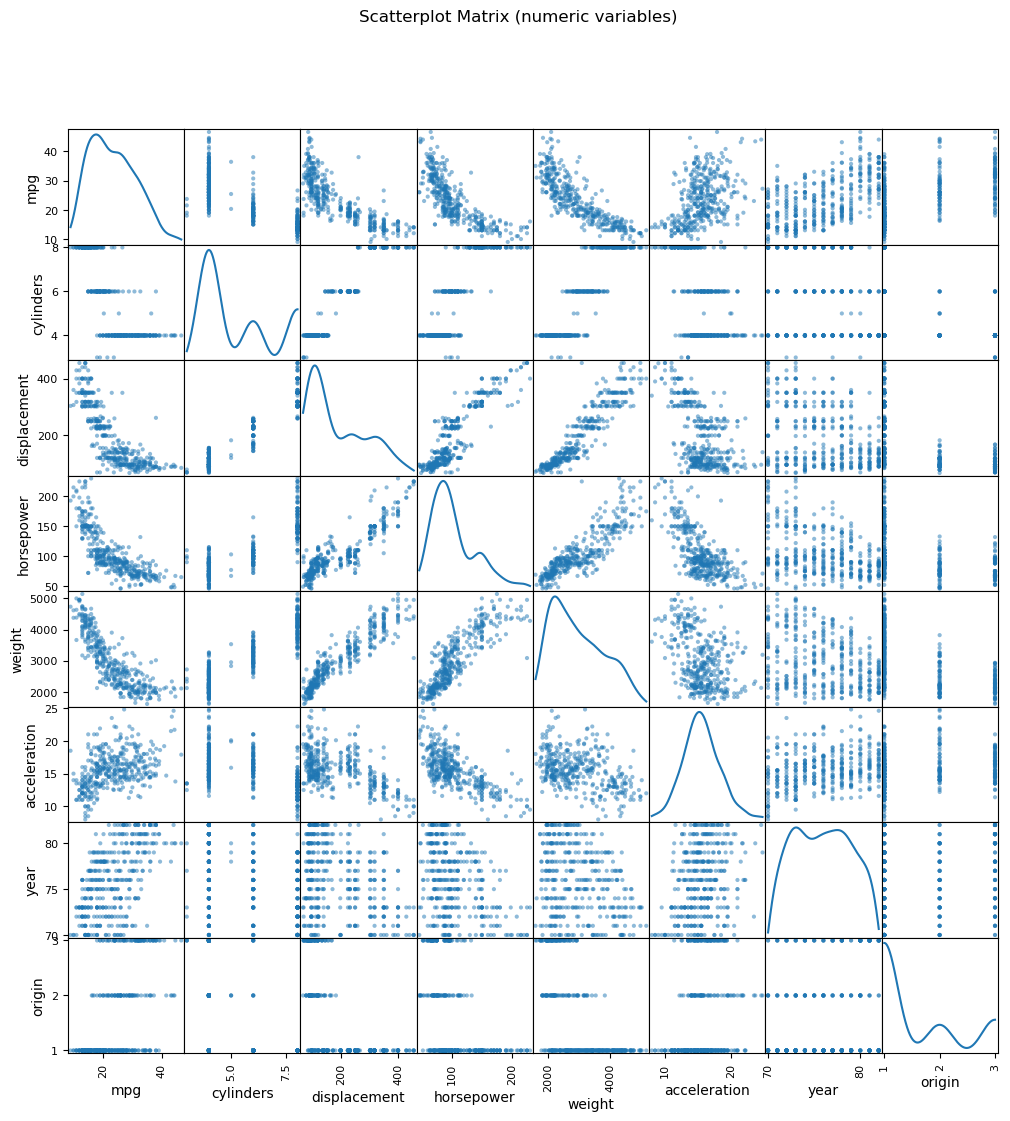

In [31]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

scatter_matrix(df[num_cols], figsize=(12,12), diagonal='kde')
plt.suptitle("Scatterplot Matrix (numeric variables)")
plt.show()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
mpg,1.000000,-0.777618,-0.805127,-0.778427,-0.832244,0.423329,0.580541,0.565209
cylinders,-0.777618,1.000000,0.950823,0.842983,0.897527,-0.504683,-0.345647,-0.568932
displacement,-0.805127,0.950823,1.000000,0.897257,0.932994,-0.543800,-0.369855,-0.614535
horsepower,-0.778427,0.842983,0.897257,1.000000,0.864538,-0.689196,-0.416361,-0.455171
weight,-0.832244,0.897527,0.932994,0.864538,1.000000,-0.416839,-0.309120,-0.585005
acceleration,0.423329,-0.504683,-0.543800,-0.689196,-0.416839,1.000000,0.290316,0.212746
year,0.580541,-0.345647,-0.369855,-0.416361,-0.309120,0.290316,1.000000,0.181528
origin,0.565209,-0.568932,-0.614535,-0.455171,-0.585005,0.212746,0.181528,1.000000


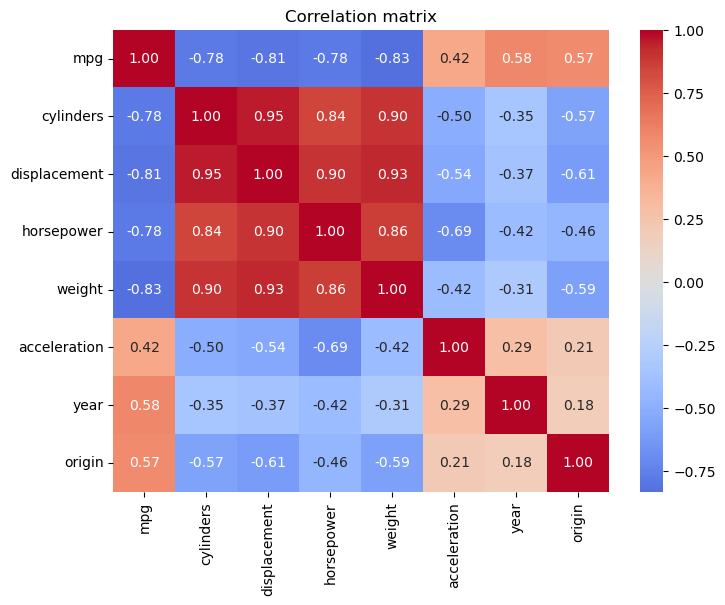

In [33]:
corrmat = df[num_cols].corr()
display(corrmat)

plt.figure(figsize=(8,6))
sns.heatmap(corrmat, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("Correlation matrix")
plt.show()

In [68]:
predictors = [c for c in df.columns if c != 'mpg' and c != 'name']

formula_terms = []
for p in predictors:
    if df[p].dtype == object:
        df[p] = df[p].astype('category')
        formula_terms.append(f"C({p})")
    else:
        if p.lower() in ['origin','yr','year','model_year'] and df[p].nunique() <= 10:
            df[p] = df[p].astype('category')
            formula_terms.append(f"C({p})")
        else:
            formula_terms.append(p)

model = smf.ols(formula=formula, data=df).fit()
print(model.summary())

print("\nANOVA table:")
anova_results = anova_lm(model)
print(anova_results)

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.866
Model:                            OLS   Adj. R-squared:                  0.862
Method:                 Least Squares   F-statistic:                     222.6
Date:                Sun, 19 Oct 2025   Prob (F-statistic):          4.44e-158
Time:                        22:26:51   Log-Likelihood:                -967.76
No. Observations:                 392   AIC:                             1960.
Df Residuals:                     380   BIC:                             2007.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept         130.0605     44.636     

In [60]:
result=smf.ols('y~X',data=df).fit()
anova_lm(result)

,df,sum_sq,mean_sq,F,PR(>F)
X,2.0,14435.090182,7217.545091,299.900684,1.335761e-79
Residual,390.0,9385.915872,24.066451,NaN,NaN


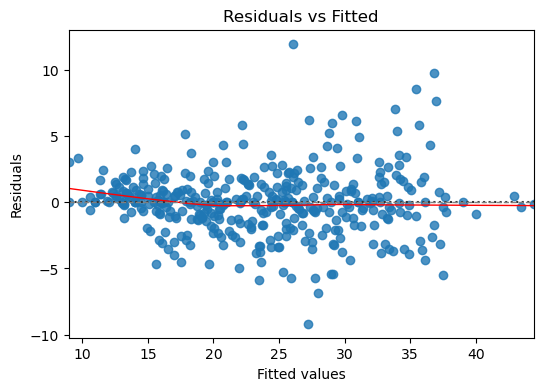

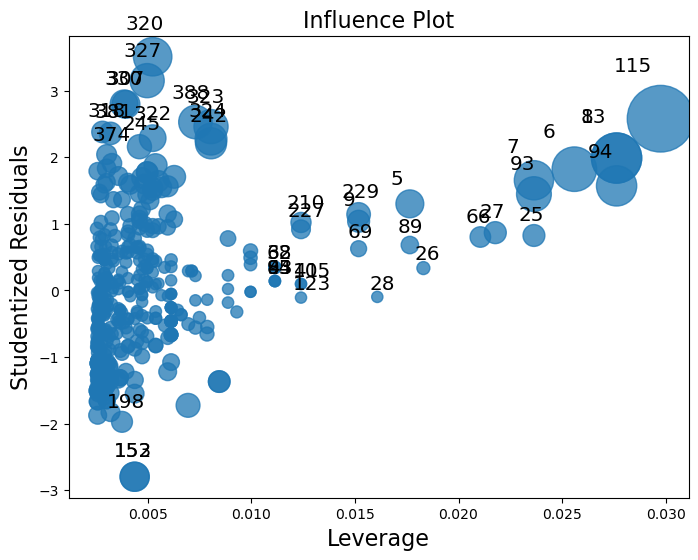

In [47]:
X = sm.add_constant(df['horsepower'])
y = df['mpg']
model = sm.OLS(y, X).fit()

fig, ax = plt.subplots(figsize=(8,6))
sm.graphics.influence_plot(model, ax=ax, criterion="cooks")
plt.show()


In [53]:
# 建幾個常見變換範例
df['log_weight'] = np.log(df['weight'])
df['sqrt_horsepower'] = np.sqrt(df['horsepower'].clip(lower=0))  # 若有 0 值要處理
df['disp_sq'] = df['displacement'] ** 2

# 範例模型：用 log(weight) 與 sqrt(horsepower)
formula_t = "mpg ~ cylinders + displacement + sqrt_horsepower + log_weight + acceleration + C(origin) + year"
model_t = smf.ols(formula=formula_t, data=df).fit()
print(model_t.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.851
Model:                            OLS   Adj. R-squared:                  0.847
Method:                 Least Squares   F-statistic:                     272.5
Date:                Sun, 19 Oct 2025   Prob (F-statistic):          6.18e-153
Time:                        22:06:29   Log-Likelihood:                -988.64
No. Observations:                 392   AIC:                             1995.
Df Residuals:                     383   BIC:                             2031.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept         130.8015     11.482     